# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
from scripts.classifiers.neural_net import TwoLayerNet
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5


def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)


def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y


net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print("Your scores:")
print(scores)
print()
print("correct scores:")
correct_scores = np.asarray(
    [
        [-0.81233741, -1.27654624, -0.70335995],
        [-0.17129677, -1.18803311, -0.47310444],
        [-0.51590475, -1.01354314, -0.8504215],
        [-0.15419291, -0.48629638, -0.52901952],
        [-0.00618733, -0.12435261, -0.15226949],
    ]
)
print(correct_scores)
print()


print("Difference between your scores and correct scores:")
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print("Difference between your loss and correct loss:")
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print(
        "%s max relative error: %e"
        % (param_name, rel_error(param_grad_num, grads[param_name]))
    )

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


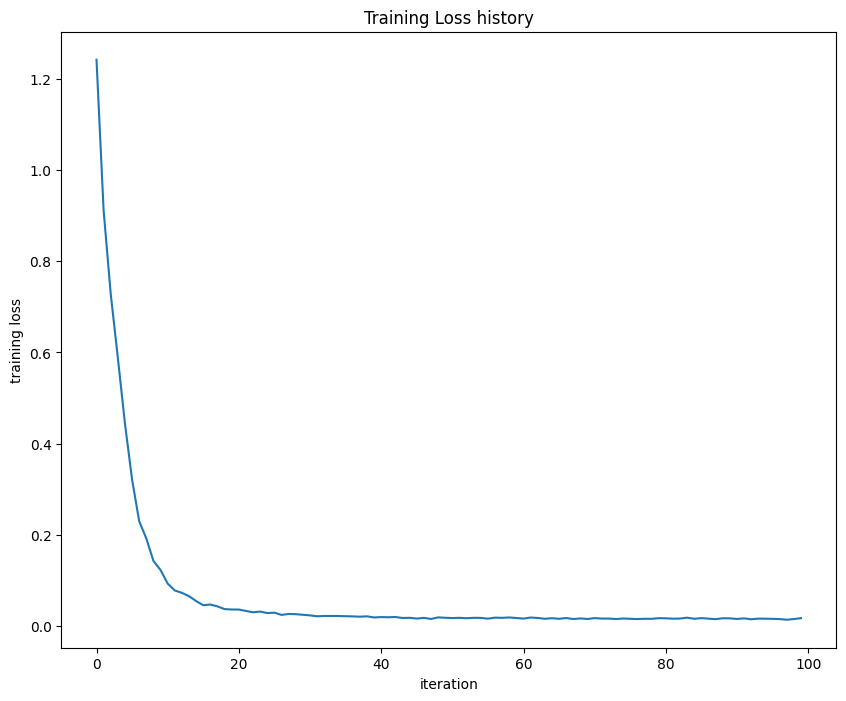

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y, learning_rate=1e-1, reg=5e-6, num_iters=100, verbose=False)

print("Final training loss: ", stats["loss_history"][-1])


plt.plot(stats["loss_history"])
plt.xlabel("iteration")
plt.ylabel("training loss")
plt.title("Training Loss history")
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

## Загрузка данных и сплит на train/val/test выборки

In [7]:
digits = load_digits()

X = digits.images
y = digits.target

X_flattened = X.reshape((len(X), -1))

X_train, X_temp, y_train, y_temp = train_test_split(
    X_flattened,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp,
)

print("=== Reshape results ===")
print(f"Original data form (X): {X.shape}")
print(f"Form after vectorization (X_flattened): {X_flattened.shape}")
print("-" * 33)
print(f"X_train: {X_train.shape}")
print(f"X_val:  {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:  {y_val.shape}")
print(f"y_test:  {y_test.shape}")

=== Reshape results ===
Original data form (X): (1797, 8, 8)
Form after vectorization (X_flattened): (1797, 64)
---------------------------------
X_train: (1437, 64)
X_val:  (180, 64)
X_test:  (180, 64)
y_train: (1437,)
y_val:  (180,)
y_test:  (180,)


## Предобработка данных из лр1

In [8]:
mean_image = np.mean(X_train, axis=0)

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

## Обучение сети

In [9]:
input_size = X_train.shape[1]
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(
    X_train,
    y_train,
    X_val,
    y_val,
    num_iters=1000,
    batch_size=200,
    learning_rate=1e-4,
    learning_rate_decay=0.95,
    reg=0.25,
    verbose=True,
)

val_acc = (net.predict(X_val) == y_val).mean()
print("Validation accuracy: ", val_acc)

iteration 0 / 1000: loss 2.302594
iteration 100 / 1000: loss 2.302596
iteration 200 / 1000: loss 2.302594
iteration 300 / 1000: loss 2.302594
iteration 400 / 1000: loss 2.302594
iteration 500 / 1000: loss 2.302593
iteration 600 / 1000: loss 2.302593
iteration 700 / 1000: loss 2.302594
iteration 800 / 1000: loss 2.302595
iteration 900 / 1000: loss 2.302594
Validation accuracy:  0.1


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

In [10]:
hidden_sizes = [64, 128, 256]
learning_rates = [1e-1, 5e-2, 1e-2]
learning_rate_decays = [0.95, 0.99]
regularization_strengths = [1e-4, 1e-3, 1e-2, 1e-1]

best_net = None
best_stats = None
best_config = None
best_val_acc = -1.0
results = {}

input_size = X_train.shape[1]
num_classes = 10
num_iters_option = [1500, 2000, 2500]
batch_size = 200

for hs, lr, decay, reg, num_iters in product(
    hidden_sizes,
    learning_rates,
    learning_rate_decays,
    regularization_strengths,
    num_iters_option,
):
    np.random.seed(42)
    net = TwoLayerNet(input_size, hs, num_classes)

    stats = net.train(
        X_train,
        y_train,
        X_val,
        y_val,
        num_iters=num_iters,
        batch_size=batch_size,
        learning_rate=lr,
        learning_rate_decay=decay,
        reg=reg,
        verbose=False,
    )

    val_acc = (net.predict(X_val) == y_val).mean()
    config = (hs, lr, decay, reg, num_iters)
    results[config] = val_acc

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_net = net
        best_stats = stats
        best_config = config


print(
    "Best config: \n",
    "hidden_size={}, lr={}, decay={}, reg={}, num_iters={}".format(*best_config),
)
print(f"Best Val Acc: {best_val_acc:.4f}")
test_acc = (best_net.predict(X_test) == y_test).mean()
print(f"Test Acc: {test_acc:.4f}")

Best config: 
 hidden_size=128, lr=0.1, decay=0.99, reg=0.01, num_iters=1500
Best Val Acc: 0.9833
Test Acc: 0.9611


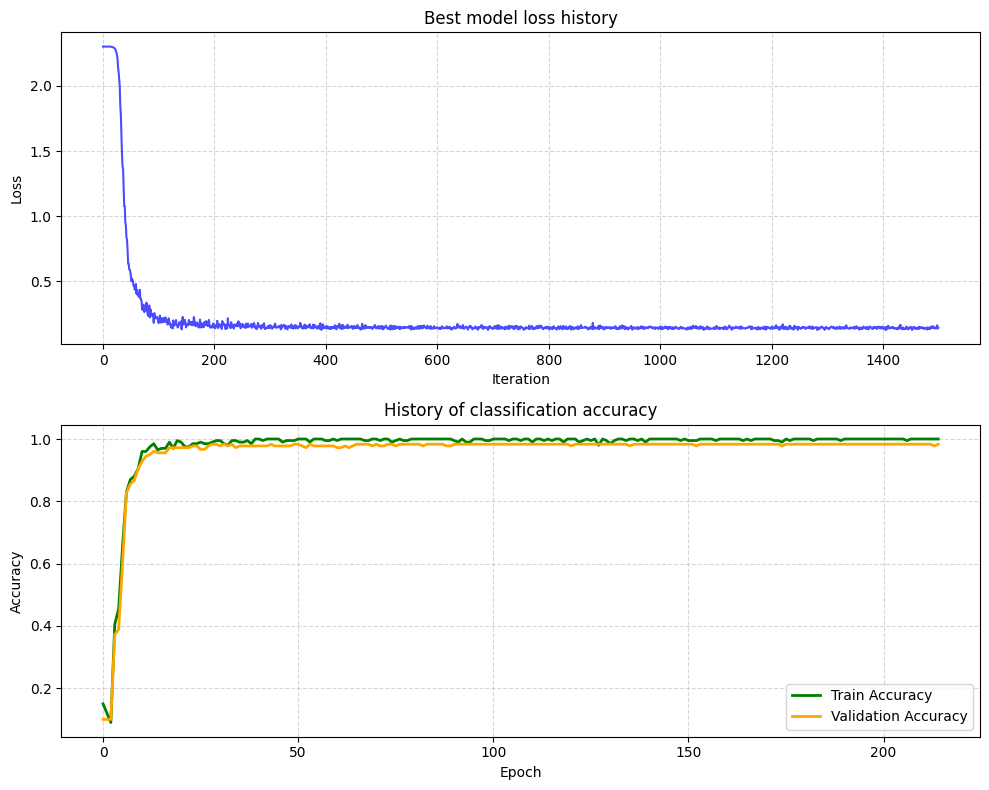

In [11]:
plt.subplot(2, 1, 1)
plt.plot(best_stats["loss_history"], color="blue", alpha=0.7)
plt.title("Best model loss history")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(2, 1, 2)
plt.plot(
    best_stats["train_acc_history"],
    label="Train Accuracy",
    color="green",
    linewidth=2,
)
plt.plot(
    best_stats["val_acc_history"],
    label="Validation Accuracy",
    color="orange",
    linewidth=2,
)
plt.title("History of classification accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

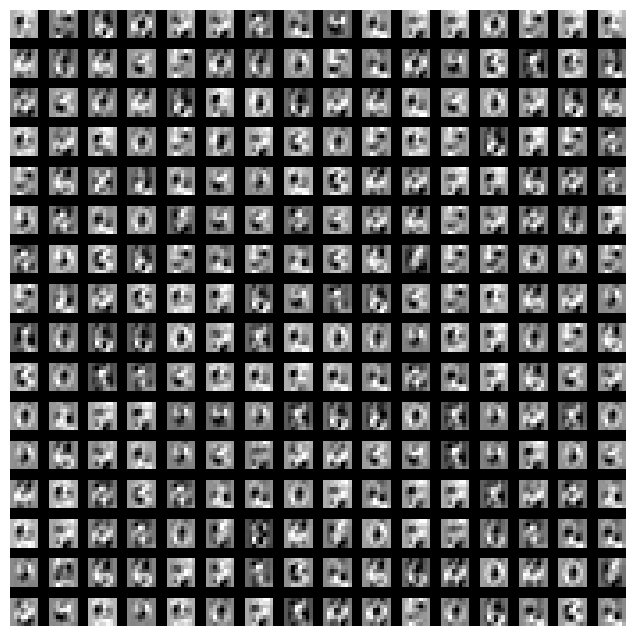

In [12]:
from scripts.vis_utils import visualize_grid


def show_net_weights(net):
    W1 = net.params["W1"].T.reshape(-1, 8, 8, 1)
    plt.imshow(visualize_grid(W1, padding=3).astype("uint8"))
    plt.gca().axis("off")
    plt.show()


show_net_weights(net)

Сделайте выводы по результатам работы. 

По результатам лабораторной работы была реализована и проверена двухслойная полносвязная нейронная сеть. На модельных данных прямой проход, вычисление функции потерь и обратное распространение ошибки показали очень малую погрешность, что подтверждает корректность реализации.

На наборе load_digits сеть после предобработки данных с гиперпараметрами по умолчанию показала низкую точность, но после предобработки данных и настройки гиперпараметров показала высокое качество классификации. Лучшая конфигурация позволила получить accuracy на валидационной выборке около 0.9833 и accuracy на тестовой выборке около 0.9611. Это показывает, что двухслойная нейронная сеть успешно решает задачу распознавания рукописных цифр, а подбор гиперпараметров позволяет заметно улучшить итоговое качество модели.